Marketing Funnel & Conversion Performance Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("d2c_marketing_funnel_data.csv")

In [3]:
df.head()

,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,discount_applied,order_value,revenue
0,221958,1,8/16/2025,2025-08,Organic,New Launch,Mobile,New,Metro,Yes,No,No,No,No,No,499.00,0.000
1,771155,2,12/16/2025,2025-12,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,Yes,No,No,No,499.00,0.000
2,231932,3,7/17/2025,2025-07,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,No,No,No,No,499.00,0.000
3,465838,4,7/4/2025,2025-07,Paid Ads,Discount,Mobile,Returning,Metro,Yes,Yes,Yes,Yes,Yes,Yes,2000.95,1800.855
4,359178,5,8/10/2025,2025-08,Paid Ads,Influencer,Mobile,Returning,Non-Metro,Yes,No,No,No,No,No,499.00,0.000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             120000 non-null  int64  
 1   session_id          120000 non-null  int64  
 2   date                120000 non-null  object 
 3   month               120000 non-null  object 
 4   channel             120000 non-null  object 
 5   campaign_type       120000 non-null  object 
 6   device              120000 non-null  object 
 7   user_type           120000 non-null  object 
 8   region              120000 non-null  object 
 9   visited_website     120000 non-null  object 
 10  viewed_product      120000 non-null  object 
 11  added_to_cart       120000 non-null  object 
 12  checkout_started    120000 non-null  object 
 13  purchase_completed  120000 non-null  object 
 14  discount_applied    120000 non-null  object 
 15  order_value         120000 non-nul

In [5]:
df.shape

(120000, 17)

In [6]:
df.describe()

,user_id,session_id,order_value,revenue
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,550415.994975,60000.500000,614.962675,141.804993
std,260166.757967,34641.160489,456.130268,545.359126
min,100005.000000,1.000000,499.000000,0.000000
25%,325121.000000,30000.750000,499.000000,0.000000
50%,551419.000000,60000.500000,499.000000,0.000000
75%,775713.250000,90000.250000,499.000000,0.000000
max,999998.000000,120000.000000,4741.370000,4741.370000


In [7]:
df.isnull().sum()

user_id               0
session_id            0
date                  0
month                 0
channel               0
campaign_type         0
device                0
user_type             0
region                0
visited_website       0
viewed_product        0
added_to_cart         0
checkout_started      0
purchase_completed    0
discount_applied      0
order_value           0
revenue               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['user_id', 'session_id', 'date', 'month', 'channel', 'campaign_type',
       'device', 'user_type', 'region', 'visited_website', 'viewed_product',
       'added_to_cart', 'checkout_started', 'purchase_completed',
       'discount_applied', 'order_value', 'revenue'],
      dtype='object')

In [11]:
df['channel'].unique()

array(['Organic', 'Paid Ads', 'Social', 'Email'], dtype=object)

In [12]:
df['campaign_type'].unique()

array(['New Launch', 'Influencer', 'Discount'], dtype=object)

In [13]:
df['device'].unique()

array(['Mobile', 'Desktop'], dtype=object)

In [14]:
df['user_type'].unique()

array(['New', 'Returning'], dtype=object)

In [15]:
df['region'].unique()

array(['Metro', 'Non-Metro'], dtype=object)

In [18]:
df['visited_website'].value_counts()

visited_website
Yes    120000
Name: count, dtype: int64

In [19]:
df['viewed_product'].value_counts()

viewed_product
Yes    77870
No     42130
Name: count, dtype: int64

In [20]:
df['added_to_cart'].value_counts()

added_to_cart
No     92844
Yes    27156
Name: count, dtype: int64

In [21]:
df['checkout_started'].value_counts()

checkout_started
No     103766
Yes     16234
Name: count, dtype: int64

In [22]:
df['purchase_completed'].value_counts()

purchase_completed
No     111819
Yes      8181
Name: count, dtype: int64

In [23]:
funnel_counts = {
    'Visited Website': (df['visited_website'] == 'Yes').sum(),
    'Viewed Product': (df['viewed_product'] == 'Yes').sum(),
    'Added to Cart': (df['added_to_cart'] == 'Yes').sum(),
    'Checkout Started': (df['checkout_started'] == 'Yes').sum(),
    'Purchase Completed': (df['purchase_completed'] == 'Yes').sum()
}

funnel_counts

{'Visited Website': np.int64(120000),
 'Viewed Product': np.int64(77870),
 'Added to Cart': np.int64(27156),
 'Checkout Started': np.int64(16234),
 'Purchase Completed': np.int64(8181)}

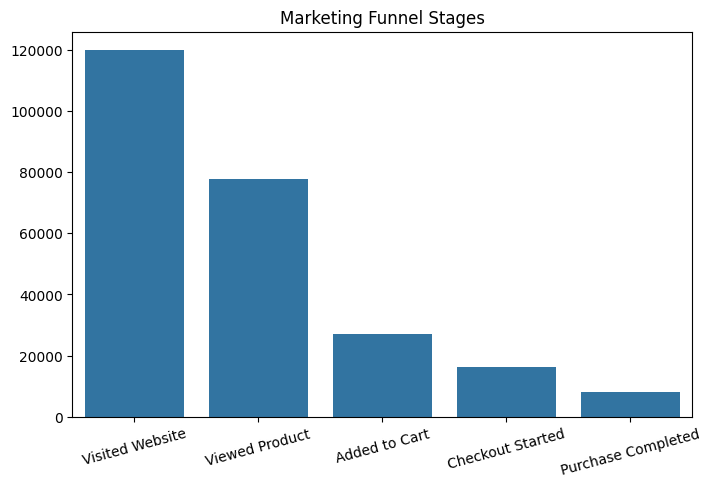

In [24]:
stages = list(funnel_counts.keys())
values = list(funnel_counts.values())

plt.figure(figsize=(8,5))

sns.barplot(x=stages, y=values)

plt.title("Marketing Funnel Stages")

plt.xticks(rotation=15)

plt.show()

In [25]:
website_to_product = (
    (df['viewed_product'] == 'Yes').sum() /
    (df['visited_website'] == 'Yes').sum()
) * 100

print(website_to_product)

64.89166666666667


In [26]:
product_to_cart = (
    (df['added_to_cart'] == 'Yes').sum() /
    (df['viewed_product'] == 'Yes').sum()
) * 100

print(product_to_cart)

34.87350712726339


In [27]:
cart_to_checkout = (
    (df['checkout_started'] == 'Yes').sum() /
    (df['added_to_cart'] == 'Yes').sum()
) * 100

print(cart_to_checkout)

59.78052732361172


In [30]:
checkout_to_purchase = (
    (df['purchase_completed'] == 'Yes').sum() /
    (df['checkout_started'] == 'Yes').sum()
) * 100

print(checkout_to_purchase)

50.39423432302574


In [29]:
channel_data = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

channel_data

channel
Paid Ads    7536147.080
Organic     5090708.447
Social      2578443.312
Email       1811300.315
Name: revenue, dtype: float64

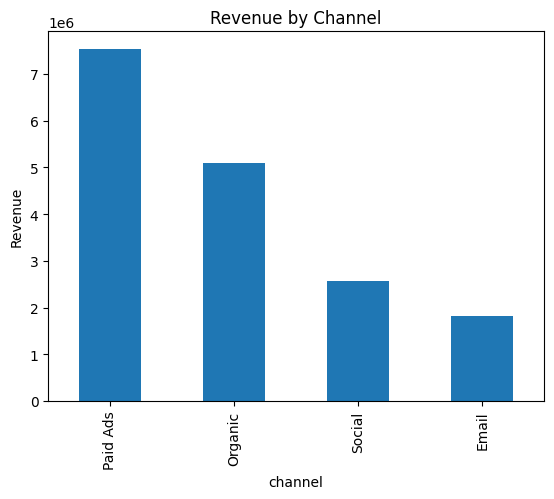

In [31]:
channel_data.plot(kind='bar')

plt.title("Revenue by Channel")

plt.ylabel("Revenue")

plt.show()

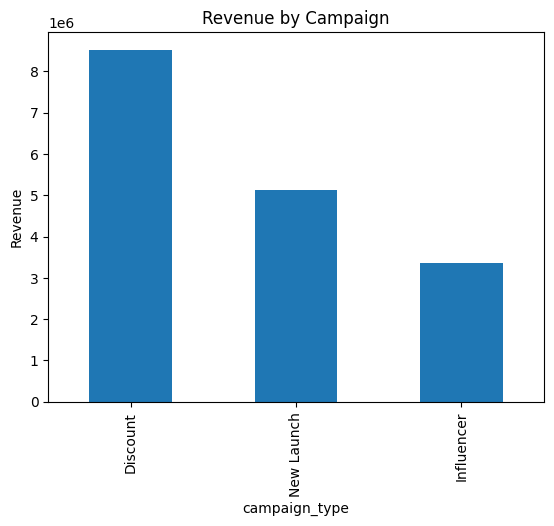

In [32]:
campaign_data = df.groupby('campaign_type')['revenue'].sum().sort_values(ascending=False)

campaign_data.plot(kind='bar')

plt.title("Revenue by Campaign")

plt.ylabel("Revenue")

plt.show()

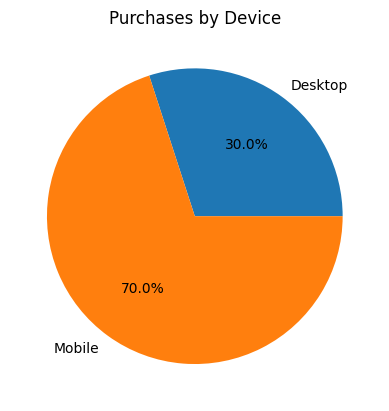

In [33]:
device_data = df.groupby('device')['purchase_completed'].count()

device_data.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")

plt.title("Purchases by Device")

plt.show()

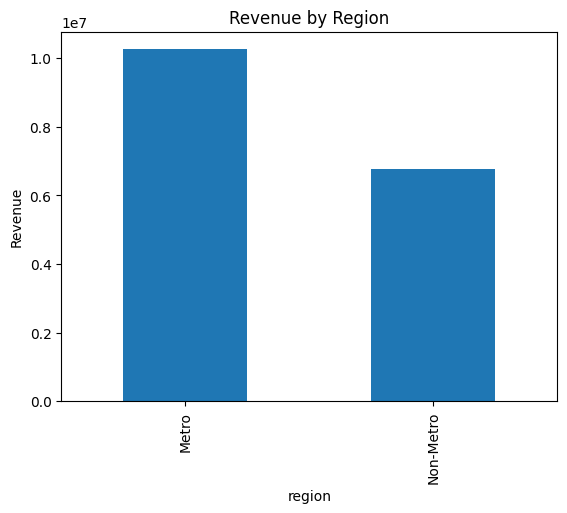

In [34]:
region_data = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

region_data.plot(kind='bar')

plt.title("Revenue by Region")

plt.ylabel("Revenue")

plt.show()

In [36]:
numeric_df = df.select_dtypes(include=np.number)

In [37]:
corr = numeric_df.corr()

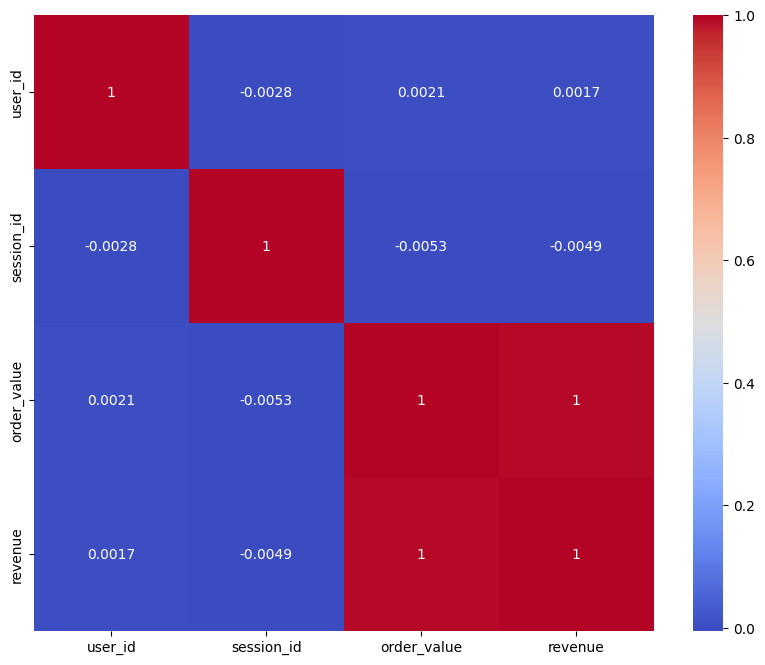

In [39]:
plt.figure(figsize=(10,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.show()

In [40]:
df.to_csv("cleaned_MarketFunnel_data.csv", index=False)